## Leveraging Poster and Trailer-Audio Embeddings for Cold-Start Movie Recommendation

## Step 1: Load Libraries and Data

In [1]:
# Load all Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import os
import json

In [4]:
# Load Datasets

ratings = pd.read_csv("../../../ml-20m/ratings.csv")
movies = pd.read_csv("../../../ml-20m/movies.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (20000263, 4)
Movies shape: (27278, 3)


## Step 2: Data Profiling & Preprocessing

In [5]:
# Inspect the Data

display(ratings.head())
display(movies.head())

print("Ratings Info:\n")
print(ratings.info())
print("\nMovies Info:\n")
print(movies.info())

print("Unique values in Ratings:\n")
print(ratings.nunique())
print("Unique values in Movies:\n")
print(movies.nunique())

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB
None

Movies Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
None
Unique values in Ratings:

userId         138493
movieId         26744
rating             10
timestamp    15351121
dtype: int64
Unique values in Movies:

movieId    27278
title      27262
genres      1342
dtype: int64


In [6]:
rating_movie_ids = set(ratings["movieId"])
movie_ids = set(movies["movieId"])

missing_movies = rating_movie_ids - movie_ids

print("Movie IDs in ratings:", len(rating_movie_ids))
print("Movie IDs in movies:", len(movie_ids))
print("Missing movie IDs:", len(missing_movies))

Movie IDs in ratings: 26744
Movie IDs in movies: 27278
Missing movie IDs: 0


In [8]:
clip_folder = "../../../IMG_clip-image"
clip_features = {}

for filename in os.listdir(clip_folder):
    if filename.endswith(".json"):
        path = os.path.join(clip_folder, filename)

        with open(path, "r") as f:
            data = json.load(f)
        for movie_id, embedding in data.items():
            clip_features[int(movie_id)] = embedding
print("CLIP movies:", len(clip_features))

first_movie_id = next(iter(clip_features))
print("Movie ID:", first_movie_id)
print("Embedding length:", len(clip_features[first_movie_id]))

CLIP movies: 25037
Movie ID: 1
Embedding length: 512


In [10]:
audio_folder = "../../../AUD_vggish/"
audio_features = {}

for filename in os.listdir(audio_folder):
    if filename.endswith(".json"):
        path = os.path.join(audio_folder, filename)
        with open(path, "r") as f:
            data = json.load(f)
        for movie_id, embedding in data.items():
            audio_features[int(movie_id)] = embedding
print("Audio movies:", len(audio_features))

first_movie_id = next(iter(audio_features))
print("Movie ID:", first_movie_id)
print("Embedding length:", len(audio_features[first_movie_id]))

Audio movies: 19340
Movie ID: 1
Embedding length: 128


In [11]:
movie_ids = set(movies["movieId"])
clip_ids = set(clip_features.keys())
audio_ids = set(audio_features.keys())

multimodal_ids = movie_ids & clip_ids & audio_ids

print("Movies:", len(movie_ids))
print("CLIP:", len(clip_ids))
print("Audio:", len(audio_ids))
print("All three:", len(multimodal_ids))

Movies: 27278
CLIP: 25037
Audio: 19340
All three: 19232


In [12]:
multimodal_movies = movies[movies["movieId"].isin(multimodal_ids)].copy()
multimodal_movies.shape

(19232, 3)

In [13]:
multimodal_movies["clip_embedding"] = (multimodal_movies["movieId"].map(clip_features))
multimodal_movies["audio_embedding"] = (multimodal_movies["movieId"].map(audio_features))

multimodal_movies.head()

,movieId,title,genres,clip_embedding,audio_embedding
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[-0.11042045056819916, 0.08279599249362946, 0....","[168.61289978027344, 18.935483932495117, 174.2..."
2,3,Grumpier Old Men (1995),Comedy|Romance,"[0.03343847393989563, -0.17208358645439148, -0...","[161.09677124023438, 17.225805282592773, 162.7..."
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[-0.35217970609664917, 0.13658151030540466, 0....","[166.48387145996094, 9.935483932495117, 178.29..."
4,5,Father of the Bride Part II (1995),Comedy,"[-0.08517539501190186, -0.35294902324676514, -...","[171.5483856201172, 18.612903594970703, 168.64..."
6,7,Sabrina (1995),Comedy|Romance,"[0.34568649530410767, -0.26137441396713257, -0...","[169.09677124023438, 10.967741966247559, 171.0..."


In [14]:
multimodal_ratings = ratings[ratings["movieId"].isin(multimodal_ids)].copy()

print("Original ratings:", len(ratings))
print("Multimodal ratings:", len(multimodal_ratings))
print("Unique users:", multimodal_ratings["userId"].nunique())
print("Unique movies:", multimodal_ratings["movieId"].nunique())

Original ratings: 20000263
Multimodal ratings: 18788341
Unique users: 138493
Unique movies: 19014


In [15]:
print ("Final DATASET") 

print("Movies:", multimodal_movies["movieId"].nunique())
print("Movies with CLIP:", multimodal_movies["clip_embedding"].notna().sum())
print("Movies with Audio:", multimodal_movies["audio_embedding"].notna().sum())
print("Ratings:", len(multimodal_ratings))
print("Users:", multimodal_ratings["userId"].nunique())

Final DATASET
Movies: 19232
Movies with CLIP: 19232
Movies with Audio: 19232
Ratings: 18788341
Users: 138493


## Step 3: Recommendation Data Analysis

In [16]:
print("Multimodal ratings shape:", multimodal_ratings.shape)
print("Unique users:", multimodal_ratings["userId"].nunique())
print("Unique movies:", multimodal_ratings["movieId"].nunique())
print("Total ratings:", len(multimodal_ratings))

Multimodal ratings shape: (18788341, 4)
Unique users: 138493
Unique movies: 19014
Total ratings: 18788341


In [17]:
ratings_per_movie = (multimodal_ratings.groupby("movieId").size())
print(ratings_per_movie.describe())

count    19014.000000
mean       988.131955
std       3564.539009
min          1.000000
25%          6.000000
50%         45.000000
75%        377.000000
max      67310.000000
dtype: float64


In [18]:
ratings_per_user = (multimodal_ratings.groupby("userId").size())
print(ratings_per_user.describe())

count    138493.000000
mean        135.662748
std         213.070912
min          12.000000
25%          33.000000
50%          64.000000
75%         146.000000
max        7741.000000
dtype: float64


In [19]:
num_users = multimodal_ratings["userId"].nunique()
num_movies = multimodal_ratings["movieId"].nunique()
num_ratings = len(multimodal_ratings)

possible_interactions = num_users * num_movies
sparsity = 1 - (num_ratings / possible_interactions)

print(f"Possible user-movie interactions: {possible_interactions:,}")
print(f"Observed ratings: {num_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Possible user-movie interactions: 2,633,305,902
Observed ratings: 18,788,341
Sparsity: 99.2865%


### Exploratory Data Analysis

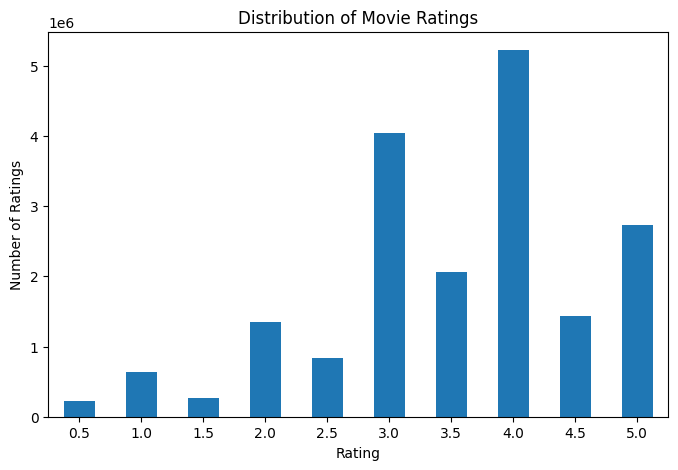

count    1.878834e+07
mean     3.525797e+00
std      1.051049e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [24]:
rating_counts = multimodal_ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

print(multimodal_ratings["rating"].describe())

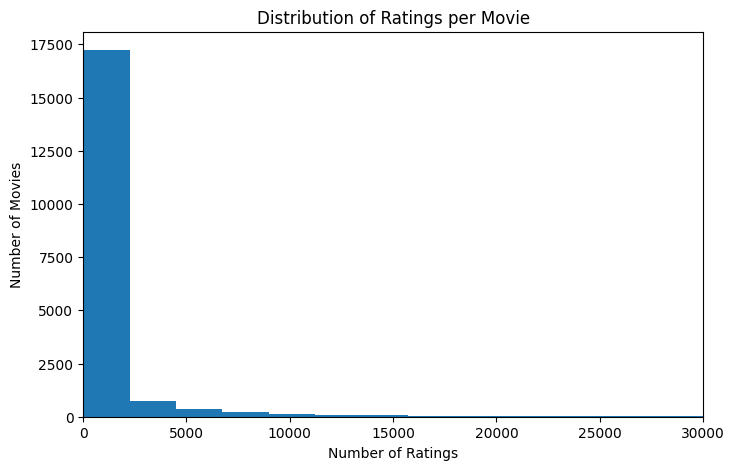

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=30)
plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.xlim(0, 30000)

plt.show()

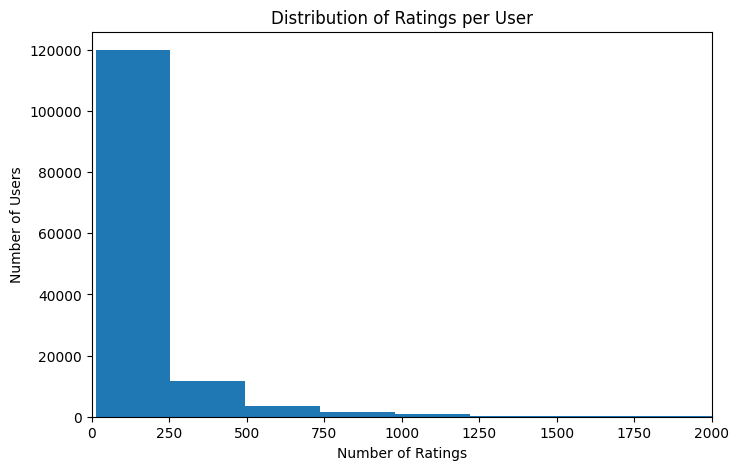

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=32)
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.xlim(0, 2000)
plt.show()

In [32]:
top_movies = (multimodal_ratings.groupby("movieId").size().sort_values(ascending=False).head(10))
print(top_movies)

movieId
296     67310
356     66172
318     63366
593     63299
480     59715
260     54502
110     53769
589     52244
2571    51334
527     50054
dtype: int64


In [33]:
top_movies_df = (top_movies.reset_index(name="rating_count").merge(multimodal_movies[["movieId", "title"]], 
                                                                   on="movieId", how="left"))
print(top_movies_df)

   movieId  rating_count                                      title
0      296         67310                        Pulp Fiction (1994)
1      356         66172                        Forrest Gump (1994)
2      318         63366           Shawshank Redemption, The (1994)
3      593         63299           Silence of the Lambs, The (1991)
4      480         59715                       Jurassic Park (1993)
5      260         54502  Star Wars: Episode IV - A New Hope (1977)
6      110         53769                          Braveheart (1995)
7      589         52244          Terminator 2: Judgment Day (1991)
8     2571         51334                         Matrix, The (1999)
9      527         50054                    Schindler's List (1993)


## Step 4: Train-Validation-Test Split

In [42]:
# Sort interactions chronologically for each user
multimodal_ratings = multimodal_ratings.sort_values(["userId", "timestamp"]).reset_index(drop=True)

# Count ratings for each user
user_rating_counts = multimodal_ratings.groupby("userId").size()

print(user_rating_counts.describe())

count    138493.000000
mean        135.662748
std         213.070912
min          12.000000
25%          33.000000
50%          64.000000
75%         146.000000
max        7741.000000
dtype: float64


In [43]:
print("Users with at least 3 ratings:", (user_rating_counts >= 3).sum())

print("Users with at least 5 ratings:", (user_rating_counts >= 5).sum())

print("Users with at least 10 ratings:", (user_rating_counts >= 10).sum())

Users with at least 3 ratings: 138493
Users with at least 5 ratings: 138493
Users with at least 10 ratings: 138493
